<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/03_Qunatum_Complexity_kappa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!rm -rf Qaos
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from gqs.states import Initial_state
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance
from gqs.dynamics import Hamiltonian_QK, floquet_operator_from_H
from gqs.PlotsDynamics import plot_two_gqs_trajectory_row
from gqs.gamma import Avg_separation_rate_local, Compare_distances_QKT, Avg_separation_QKT
from gqs.plotsCompare import Plot_Avg_Separation

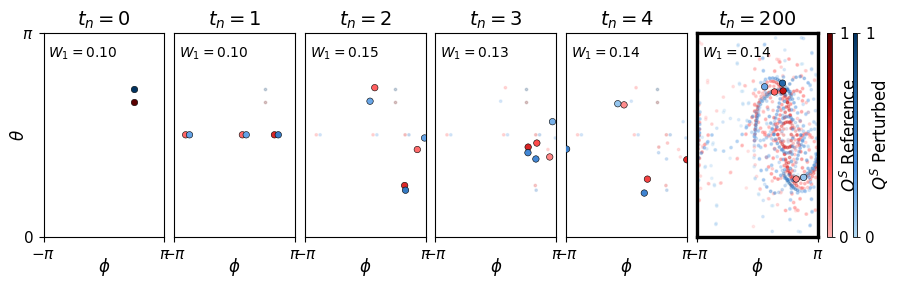

In [9]:
kappa, nqubit = 2.5, 3                                     # <--- kappa- interaction strength, nqubits - number of qubits in kicked top
H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian

# Two neighboring Global States - taken to be a spin coherent state but can be changed to a more general Psi
theta, phi, eps = np.pi/2+0.5, np.pi/2, 0.2
psi_reference = Initial_state(nqubit,theta,phi)
psi_perturbed = Initial_state(nqubit, theta+eps, phi)

#Dynamics of the reduced states
_= plot_two_gqs_trajectory_row(U_F=U_F, psi_reference=psi_reference, psi_perturbed=psi_perturbed, selected_kicks=(0,1,2,3,4,200))


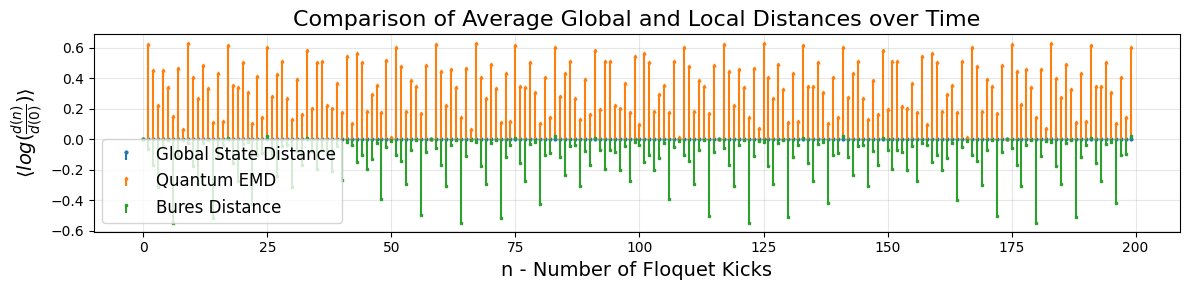

In [12]:
dhilbert, system_site = 2,0
N_traj,N_kicks = 100, 200
data_dist=Avg_separation_QKT(dhilbert,nqubit,system_site,U_F,theta,phi,eps,N_traj,N_kicks)
Plot_Avg_Separation(data_dist, N_kicks)